# Phase 4, Module 8: Ensemble Learning (The Power of Crowds)
Welcome to Module 8! In the previous module, we saw that a single Decision Tree can easily overfit if it becomes too deep. **Ensemble Learning** solves this by combining many trees together.[cite: 1]

In this notebook, we will explore:
1. **The Random Forest**: Building a collection of trees.[cite: 1]
2. **Comparison**: Proving why a Forest is more accurate than a single Tree.[cite: 1]
3. **Feature Importance**: Seeing which data columns the AI thinks are most important.[cite: 1]

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Load a more complex dataset: The Wine Dataset
wine = load_wine()
X, y = wine.data, wine.target

print("Libraries and Wine dataset loaded! Let's build a forest.")

Libraries and Wine dataset loaded! Let's build a forest.


## 1. Random Forest vs. Single Decision Tree
A Random Forest builds hundreds of trees simultaneously and takes the average.[cite: 1] Let's compare the accuracy of a single tree against a "Forest" of 100 trees on the same data.

In [2]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. Single Decision Tree
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
tree_acc = single_tree.score(X_test, y_test)

# 2. Random Forest (Ensemble of 100 trees)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
forest_acc = random_forest.score(X_test, y_test)

print(f"Single Tree Accuracy: {tree_acc * 100:.2f}%")
print(f"Random Forest Accuracy: {forest_acc * 100:.2f}%")
print("\nNotice how the ensemble of trees almost always outperforms the individual tree!")

Single Tree Accuracy: 96.30%
Random Forest Accuracy: 100.00%

Notice how the ensemble of trees almost always outperforms the individual tree!


## 2. Feature Importance
One of the coolest features of a Random Forest is that we can ask it: *"Which features were the most helpful in ranking these wines?"*[cite: 1] This allows us to see the most influential data columns.

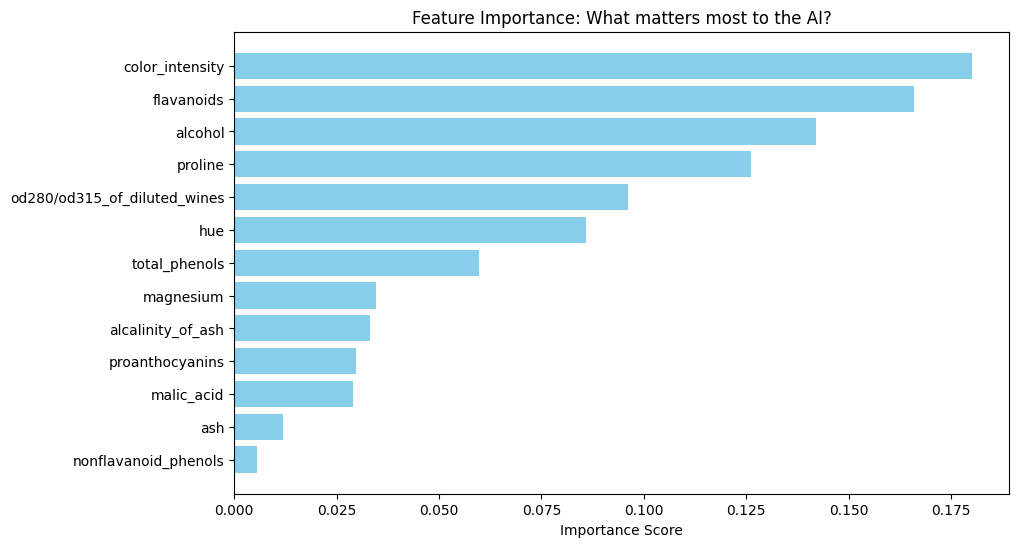

In [3]:
# Get feature importances from the forest
importances = random_forest.feature_importances_
feature_names = wine.feature_names

# Sort them for a better plot
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=True)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue')
plt.title("Feature Importance: What matters most to the AI?")
plt.xlabel("Importance Score")
plt.show()

---
## 🎓 Student Task: The "Forest of Trees" Challenge

In Task 6 of your curriculum, you are asked to upgrade a simple model to a more powerful ensemble system.[cite: 1] 

**Scenario**: You are predicting whether a student in Peshawar will pass a difficult certification exam based on:
1. `Study_Hours`
2. `Previous_GPA`
3. `Internet_Access` (1 = Yes, 0 = No)

**Your Goal**:
1. Train a `RandomForestClassifier` with `n_estimators=50` (50 trees).[cite: 1]
2. Use the `feature_importances_` attribute to find out which of the 3 features is most important to the model.[cite: 1]
3. Prove that the Random Forest has a higher accuracy than a single Decision Tree on the provided test data.[cite: 1]

In [ ]:
# TASK: Complete the Forest Upgrade

# Dataset: [Hours, GPA, Internet]
X_student = [[2, 2.5, 0], [10, 3.8, 1], [5, 3.0, 1], [1, 2.0, 0], [8, 3.5, 1], [4, 2.8, 1], [12, 3.9, 1], [3, 2.2, 0]]
y_exam = [0, 1, 1, 0, 1, 0, 1, 0] # 0 = Fail, 1 = Pass

# 1. Create and Train a Single Decision Tree (for comparison)
# tree_model = DecisionTreeClassifier(random_state=42)
# tree_model.fit(X_student, y_exam)

# 2. Create and Train a Random Forest with 50 trees
# forest_model = RandomForestClassifier(n_estimators=50, random_state=42)
# forest_model.fit(X_student, y_exam)

# 3. Identify the most important feature
# print("Feature Importances:", forest_model.feature_importances_)

# 4. Compare their results on a new student: [6 hours, 3.2 GPA, 1 Internet]
test_student = [[6, 3.2, 1]]
# print("Tree Prediction:", tree_model.predict(test_student))
# print("Forest Prediction:", forest_model.predict(test_student))